# Option hedging: simulation

## Numerical processing of financial data

Romain ETIENNE, did it solo.

#### Objective
The goal of this notebook is to simulate the dynamics of an asset price, and then to simulated the delta-hedging procedure for an option written on the asset.

In [1]:
import numpy as np

np.random.seed(12345)

## Exercice 1: Monte Carlo simulation of the hedging procedure for a Call option

### Q1: The trajectories of the underlying asset price

We need a stochastic model for the underlying asset price $S$.

We will consider the log-normal model with drift parameter $\mu \in \mathbb{R}$ and volatility parameter $\sigma > 0$,

$$
S_{t_{i+1}} = S_{t_i} \, \exp \Bigl( \mu (t_{i+1} - t_i)  + \sigma (W_{t_{i+1}} - W_{t_i}) \Bigr)
$$
 
where 

$$
W_{t_{i+1}} - W_{t_i} = \sqrt{\Delta t} \, G_i
$$

and $(G_i)_{i \ge 1}$ is a sequence of independent random variables with Gaussian distribution $\mathcal N (0,1)$.


A note : the variables $\Delta W_i = W_{t_{i+1}} - W_{t_i}$ can be interpreted as the increments of a Brownian motion $W_t$.

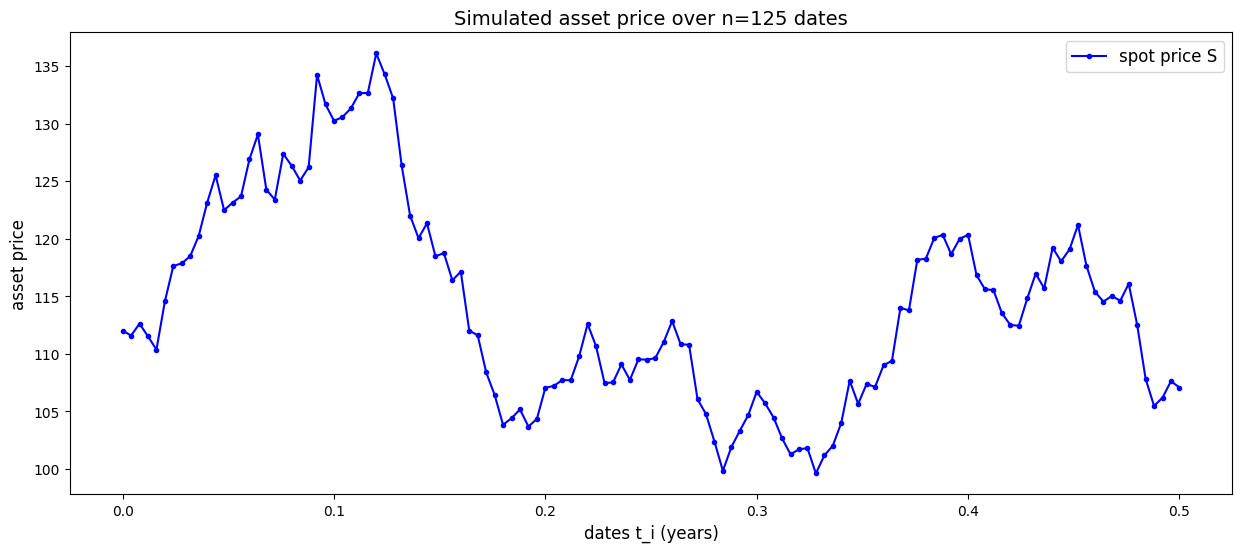

In [2]:
## Model parameters
mu = 0.02
sigma = 0.3
S_0 = 112

## Time horizon 
T = 0.5  # 0.5 years = 6 months

## Time grid t_0, t_1, ..., t_n
n = 125 # time-step = one day -> 24 * to pass to one hour
dates = np.linspace(0, T, n+1)

Delta_T = T/n

##################################
## Simulation: trajectories of S
##################################
# Let us create a vector (a numpy array, actually) containing n+1 elements
# in order to accomodate the simulated values of S_0, S_{t_1}, ... S_{t_n}
S = S_0 * np.ones(n+1)

for i in range(n):
    ## We draw one standard Gaussian using the numpy.random library
    G = np.random.randn()
    
    ## Note : each time we make a new call to the function np.random.randn,
    ## we will get an independent sample
    
    # Done
    brownian_incr = np.sqrt(Delta_T) * G
    
    # Done
    S[i+1] = S[i] * np.exp((mu*Delta_T) + sigma * brownian_incr)

######################################
## Let us plot the trajectory of S
######################################
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(dates, S, color="blue", label="spot price S", marker=".")

plt.xlabel("dates t_i (years)", fontsize=12)
plt.ylabel("asset price", fontsize=12)
plt.title("Simulated asset price over n=%1.0f dates" %n, fontsize=14)

plt.legend(loc="best", fontsize=12)
plt.show()

### Q2: Simulation of the hedging portfolio

$\bullet$ Option to hedge : call option $(S_T - K)^+$

$\bullet$ We delta hedge the option, with adjustment of the delta position at the sequence of dates $(t_0, t_1, \dots, t_{n-1})$, where $t_{i+1} - t_i = \Delta t$ and $t_{n-1} = T - \Delta t$.

$\bullet$ Reminder: the hedging portfolio has a cash part, which we denote $V^0_t$, and a delta part $\delta_t S_t$:

$$
V_{t_i} = V^0_{t_i} + \delta_{t_i} S_{t_i}.
$$

The value of the portfolio at time $t_{i+1}$ is

$$
V_{t_{i+1}} =  V^0_{t_i} (1 + r \, \Delta t) + \delta_{t_i} S_{t_{i+1}}.
$$

Therefore, the variation of wealth between time $t_i$ and $t_{i+1}$ is given by

$$
\begin{aligned}
V_{t_{i+1}} - V_{t_i} &= V^0_{t_i} \, r \, \Delta t + \delta_{t_i} ( S_{t_{i+1}} - S_{t_i} )
\\
&= (V_{t_i} - \delta_{t_i} S_{t_i}) \, r \, \Delta t + \delta_{t_i} ( S_{t_{i+1}} - S_{t_i} ).
\end{aligned}
$$

$\bullet$ In order to implement the delta-hedging strategy, we need to specify :

+ the initial value $V_0$

+ the delta position $\delta_{t_i} = \delta(t_i, S_{t_i})$ to be held between $t_i$ and $t_{i+1}$.

At every date $t_i$, the value of the cash position will be given by $V_{t_i} - \delta_{t_i} S_{t_i}$.

#### Q2 (a) The formulas: Black-Scholes again!

$\bullet$ Code (once again) the Black-Scholes formulas for the price $\mathrm{Call_{BS}}$ of the call option (so to evaluate the initial value $V_0$), and the formula for the delta $\delta_\mathrm{BS}$ that we will use to implement the dynamic hedging strategy:

$$
\begin{aligned}
\mathrm{Call_{BS}}(t,S,T,K,\hat \sigma) &= e^{-r \, (T-t)} \bigl( F_t^T\, N(d_1) - K \, N(d_2) \bigr),
\\
\delta_\mathrm{BS}(t,S,T,K, \hat \sigma) &= N(d_1)
\end{aligned}
$$

where $F_t^T = S \, e^{r \, (T-t)}$ is the forward price of $S$,

$$
d_1 = \frac 1{\hat \sigma \sqrt{T-t}} \log \frac{F_t^T}K + \frac 12 \hat\sigma \sqrt{T-t},
\qquad
d_2 = d_1 - \hat \sigma \sqrt{T-t},
$$

and $N(x) = \int_{-\infty}^x \frac 1{\sqrt{2 \pi}} e^{-\frac{y^2} 2} dy$ is the standard Gaussian cdf.

Note that we denote $\hat \sigma$ the volatility parameter used in the Black-Scholes pricing functions.
The parameter $\hat \sigma$ we use to price and hedge the option does not need to coincide with $\sigma$, the realized volatility of the asset trajectory.

In [3]:
## As usual, to access the Gaussian cdf we can exploit the function norm.cdf() from the library scipy.stats
import scipy.stats as sps

def Call_BS(t, S_t, T, K, r, sigma_hat):
    ################################################################
    # If t = T (zero time-to-maturity), we return the option payoff
    ################################################################
    if t == T:
        return (S_t - K)*(S_t >= K)
    
    else:
        sigma_sqrt_time = sigma_hat * np.sqrt(T - t)
        F = S_t * np.exp(r *(T-t))

        d_1 = np.log(F/K) / sigma_sqrt_time + 0.5 * sigma_sqrt_time
        d_2 = d_1 - sigma_sqrt_time

        price = np.exp(-r*(T-t)) * (F * sps.norm.cdf(d_1) - K * sps.norm.cdf(d_2))

        return price

def delta_BS(t, S_t, T, K, r, sigma_hat):
    # Done
    sigma_sqrt_time = sigma_hat * np.sqrt(T - t)
    
    F = S_t * np.exp(r *(T-t))
    
    d_1 = np.log(F/K) / sigma_sqrt_time + 0.5*sigma_sqrt_time
    
    delta = sps.norm.cdf(d_1)
    
    return delta

#####################################################################
## Small numerical check : with the given parameters, you should get:
## option price = 8.640, option delta = 0.511
#####################################################################
t, S_t, T, K, r, sigma_hat = 0, 112, 0.5, 115, 0.02, 0.3

print("Parameters: t=%0.1f, S_t=%0.2f, T=%0.2f, K=%0.2f, r=%0.2f, sigma=%0.2f"%(t, S_t, T, K, r, sigma_hat))
print("Option price %1.3f" %Call_BS(t=0, S_t=112, T=0.5, K=115, r=0.02, sigma_hat=0.3))
print("Option delta %1.3f" %delta_BS(t=0, S_t=112, T=0.5, K=115, r=0.02, sigma_hat=0.3))

Parameters: t=0.0, S_t=112.00, T=0.50, K=115.00, r=0.02, sigma=0.30
Option price 8.640
Option delta 0.511


#### Q2(b) Simulation of the hedging strategy

We start by resimulating a trajectory of the asset price in the cell below.

In [4]:
## Parameters of the call option
T = 0.5
K = 115

def payoff_call(S, K):
    return np.maximum(S - K, 0)

# Model parameters for the dynamics of the asset price
sigma = 0.3 # asset realized volatility

# Parameters for the price and delta functions
r = 0.02
sigma_hat = 0.3 # volatility parameter we plug into the Black-Scholes formulas (the same as sigma... for the moment)

## Hedging dates t_1, ..., t_n
n = 125
dates = np.linspace(0, T, n+1)
Delta_T = T/n

#######################################################
## Trajectory of the asset price :
## let us simulate a new trajectory inside this cell
#######################################################
G = np.random.randn(n)
# Note : the instruction np.random.randn(n) directly provides us with n independent samples of N(0,1)

# We multiply all the elements of the vector G by the standard deviation delta_T 
brownian_increments = np.sqrt(Delta_T) * G 

S = S_0 * np.ones(n+1)

for i in range(n):
    # Done
    S[i+1] = S[i] * np.exp((mu*Delta_T) + sigma * brownian_increments[i])

Below, the hedging portfolio

In [5]:
########################################################
## Hedging portfolio, constructed over the asset price
## trajectory simulated above
########################################################
# Initial option price (at time t_0 = 0)
V_0 = Call_BS(t = 0, S_t = S_0, T = T, K = K, r = r, sigma_hat = sigma)

# We create the numpy array which will accommodate the values of the heding portfolio
# over the n dates t0, ..., t_{n-1}
V = V_0 * np.ones(n+1)

for i in range(n):
    # Done: Compute delta at time t_i
    delta = delta_BS(t=dates[i], S_t=S[i], T=T, K=K, r=r, sigma_hat=sigma)

    # Done: Compute the cash at time t_i
    current_cash = V[i] - delta * S[i]

    # Done: Compute the value of the hedging portfolio at time t_{i+1}
    V[i + 1] = (
        V[i] + delta * (S[i + 1] - S[i]) + current_cash * (np.exp(r * Delta_T) - 1)
    )

###################################################
## We compare the final value of the hedging portfolio V_T
## with the option payoff
###################################################
print("Final value V_T = %1.3f" %V[n])
print("Payoff (S_T - K)^+ = %1.3f" %payoff_call(S[n], K))
print("Hedging error = %1.3f" %(V[n] - payoff_call(S[n], K)))
print("Final value delta position: delta_T = %1.3f \n" %delta)

Final value V_T = -0.116
Payoff (S_T - K)^+ = 0.000
Hedging error = -0.116
Final value delta position: delta_T = 0.000 



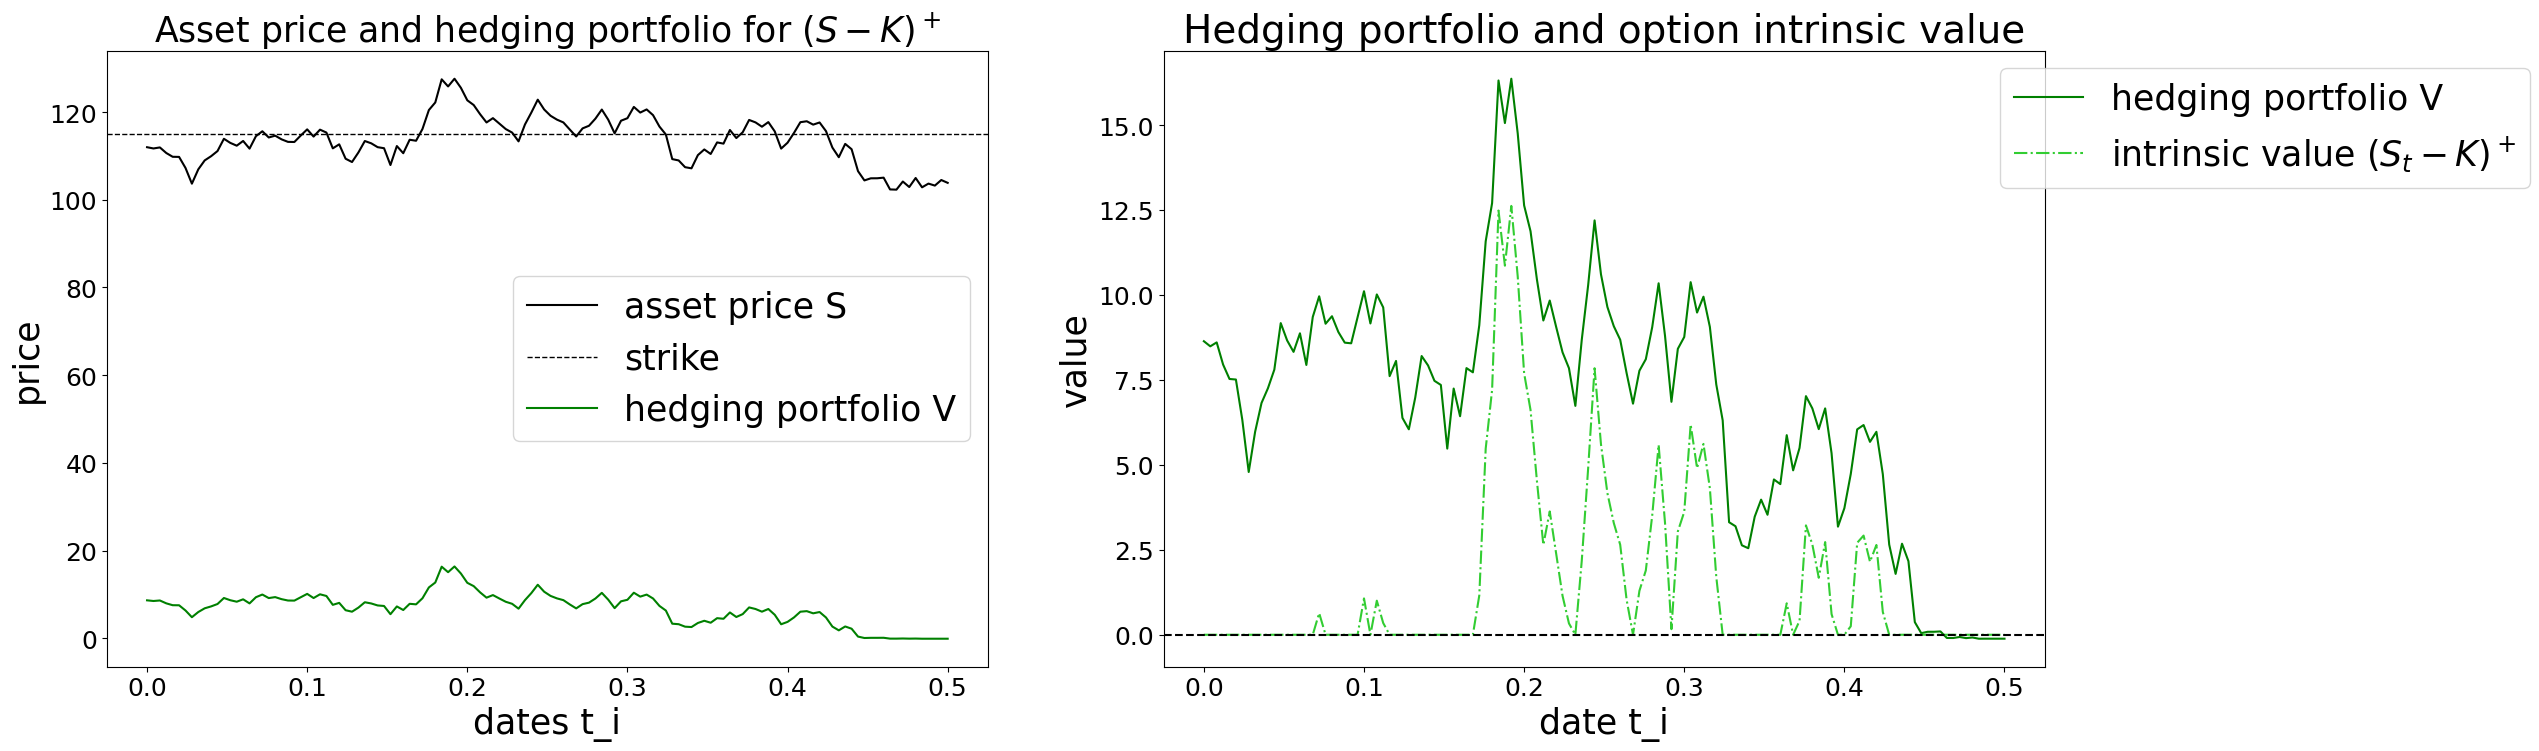

In [6]:
###############
## Plotting
###############
plt.figure(figsize=(25,8))

# Done: plot the asset price trajectory
plt.subplot(1,2,1)
plt.tick_params(labelsize=18)

plt.plot(dates, S, color="k", label="asset price S")
plt.axhline(K, linestyle='--', linewidth=1.0, color="k", label="strike")

# Done: in the same figure, plot the trajectory of the hedging portfolio
plt.plot(dates, V, color='green', label="hedging portfolio V")

plt.title("Asset price and hedging portfolio for $(S - K)^+$", fontsize=25)
plt.xlabel("dates t_i", fontsize=25)
plt.ylabel("price", fontsize=25)
plt.legend(loc="best", fontsize=25)

# Done: In the second figure, we zoom in on the hedging portfolio
plt.subplot(1,2,2)
plt.tick_params(labelsize=18)

plt.plot(dates, V , color='green', label="hedging portfolio V")

# Done
intrinsic_value = payoff_call(S, K)

plt.plot(dates, intrinsic_value, color='limegreen', linestyle='-.', label="intrinsic value $(S_t - K)^+$")

plt.axhline(0, linestyle='--', color="k")

plt.xlabel("date t_i", fontsize=25)
plt.ylabel("value", fontsize=25)
plt.title("Hedging portfolio and option intrinsic value", fontsize=28)

plt.legend(loc=9, fontsize=25, bbox_to_anchor=(1.25, 1.0), ncol=1)

plt.show()

##### __Questions__ (you can answer directly inside this text cell)

1. What do you observe ? Is the hedging perfect, do you observe a hedging error ? Can you observe the different behavior of the hedging error when the asset $S$ ends up being close to the strike $K$ at $T$, as opposed to far away from the strike K?

- The hedging is not perfect, we got a hedging error of -0.103 (first daily n).
- Behavior when S is close to K at T: the hedging error is higher, the value of the hedging portfolio is higher than the payoff, due to the gamma of the option, which is higher when S is close to K.
- Behavior when S is far from K at T: the hedging error is lower, the value of the hedging portfolio is lower than the payoff, due to the gamma of the option, which is lower when S is far from K.

2. What happens if we modify the number $n$ of hedging dates $t_i$ ? (Say we multiply the number of dates by 2, by 4, by 10... or conversely, we reduce the number of dates).

- The absolute hedging error is supposed to be reduced since we recalibrate the portfolio more often within the hours (instead of days).

## Exercise 2 - Monte Carlo simulation of several trajectories

Instead of rerunning the simulation code above several times so to observe different occurrences of the final hedging PnL, we can directly simulate several (independent) trajectories at once.

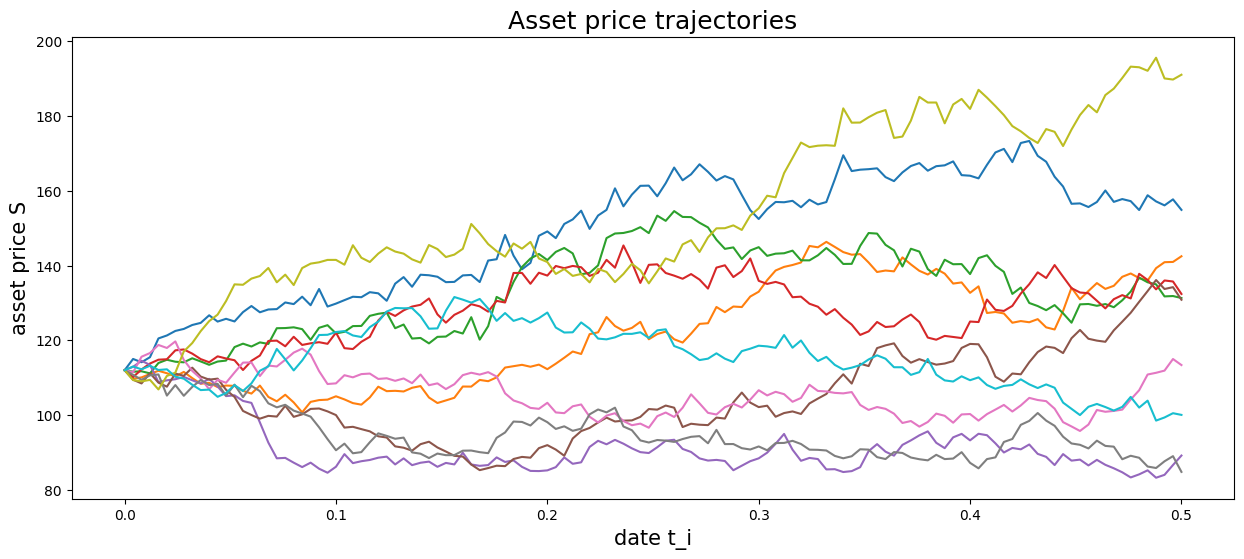

In [7]:
## Model parameters
mu = 0.02
sigma = 0.3
S_0 = 112

## Time horizon 
T = 0.5

## Time grid t_0, t_1, ..., t_n
n = 125
dates = np.linspace(0, T, n+1)
Delta_T = T/n

# Number of simulated trajectories
M = 500

##################################
## Simulation: trajectories of S
##################################
# Let us create an array of size M x (n+1)
# in order to accomodate the M different trajectories S_0, S_{t_1}, ... S_{t_n}
# of the asset price
S = S_0 * np.ones((M, n+1))

for i in range(n):
    ## We directly draw M i.i.d. standard Gaussians using the numpy.random library
    G = np.random.randn(M)
        
    # Done
    S[:, i+1] = S[:, i] * np.exp((mu*Delta_T) + sigma * np.sqrt(Delta_T) * G)
    

###################################################
## Let us plot the first 10 simulated trajectories
###################################################
# Number of trajectories to plot
M_1 = 10

# We select the first M_1 trajectories
trajectories_to_plot = S[:M_1, :]

plt.figure(figsize=(15,6))
plt.plot(dates, trajectories_to_plot.T)  # .T to obtain good dimension.

plt.title("Asset price trajectories", fontsize=18)
plt.xlabel("date t_i", fontsize=15)
plt.ylabel("asset price S", fontsize=15)
plt.show()

$\blacktriangleright$ Simulation of the call option hedging: now several trajectories at once.

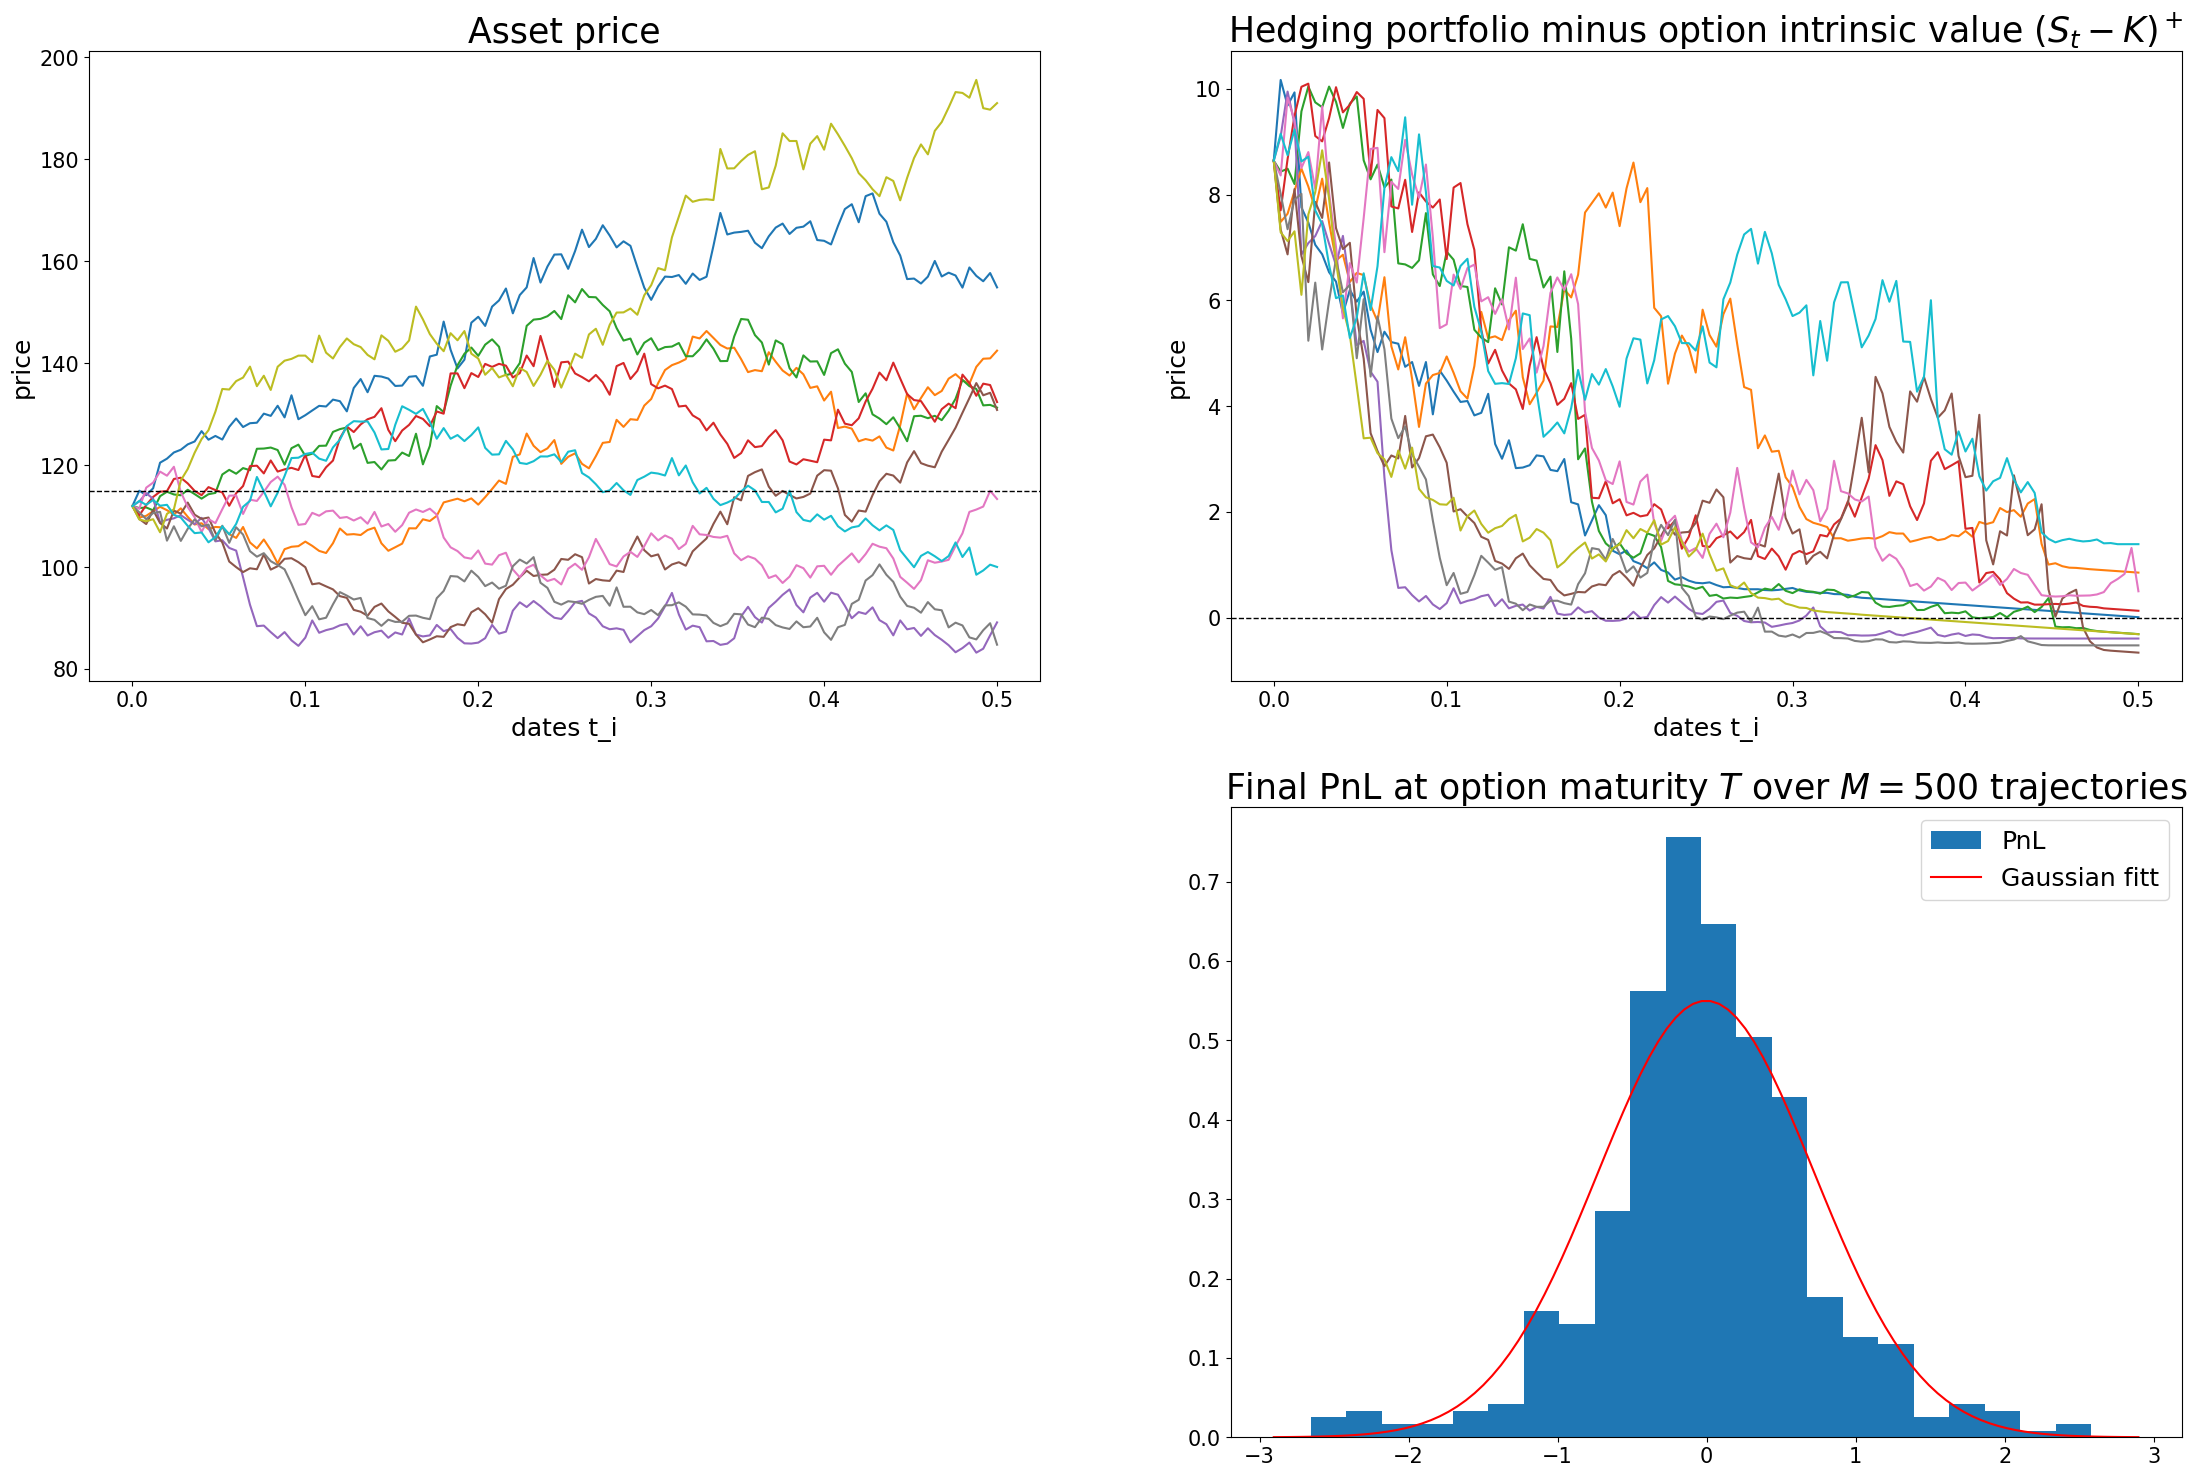

In [8]:
# Parameters for the Black-Scholes price and delta
r = 0.02
sigma_hat = 0.3

########################################################
## Hedging portfolio, constructed over the asset price
## trajectory simulated above 
########################################################
# Initial option price (at time t_0 = 0)
V_0 = Call_BS(t=0, S_t=S_0, T=T, K=K, r=r, sigma_hat=sigma_hat)

# We create the numpy array with size M * (n+1) which will accommodate 
# the values of the heding portfolioover the n dates t0, ..., t_{n-1}
# and for all the simulated trajectories
V = V_0 * np.ones((M, n+1))

for i in range(n):
    # Done: evalute the delta position at the current date t_i
    delta = delta_BS(t=dates[i], S_t=S[:, i], T=T, K=K, r=r, sigma_hat=sigma_hat)
        
    # Done: evaluate the variation V_{t_{i+1}} - V_{t_i} of the portfolio value, then update V_{t_{i+1}} 
    portfolio_variation = delta * (S[:, i + 1] - S[:, i]) + (V[:, i] - delta * S[:, i]) * (np.exp(r * Delta_T) - 1)
    V[:, i + 1] = V[:, i] + portfolio_variation
    
###############
## Plotting
###############
plt.figure(figsize=(27,18))

# Done: plot 10 asset price trajectories
plt.subplot(2,2,1)
plt.tick_params(labelsize=15)

M_1 = 10

plt.plot(dates, S[:M_1, :].T)
plt.axhline(K, linestyle='--', linewidth=1.0, color="k", label="strike")

plt.title("Asset price", fontsize=25)
plt.xlabel("dates t_i", fontsize=18)
plt.ylabel("price", fontsize=18)

# Done: plot the corresponding 10 trajectories of the difference between the hedging portfolio
# and the option's intrinsic value
plt.subplot(2,2,2)
plt.tick_params(labelsize=15)

intrinsic_value = payoff_call(S[:M_1, :], K)

plt.plot(dates, V[:M_1, :].T - intrinsic_value.T)
plt.axhline(y=0, linestyle='--', linewidth=1.0, color="k")

plt.title("Hedging portfolio minus option intrinsic value $(S_t - K)^+$", fontsize=25)
plt.xlabel("dates t_i", fontsize=18)
plt.ylabel("price", fontsize=18)

################################################################################
# Last plot: let us show the histogram of the final PnL (at the option maturity),
# now using all the M simulated trajectories
#################################################################################
plt.subplot(2,2,4)
plt.tick_params(labelsize=15)

PnL_at_maturity = V[:, -1] - payoff_call(S[:, -1], K)

plt.hist(PnL_at_maturity, bins=int(np.sqrt(M)), density="True", label="PnL")  # type: ignore

plt.title("Final PnL at option maturity $T$ over $M=%1.0f$ trajectories" %M, fontsize=25)

# For pleasure
avg_PnL, std_PnL = np.mean(PnL_at_maturity), np.std(PnL_at_maturity)
plt.plot(np.linspace(avg_PnL - 4*std_PnL, avg_PnL + 4*std_PnL, 100),
         sps.norm.pdf(np.linspace(avg_PnL - 4*std_PnL, avg_PnL + 4*std_PnL, 100), loc=avg_PnL, scale=std_PnL),
         color="red", label="Gaussian fitt")

plt.legend(loc="best", fontsize=18)

plt.show()

$\blacktriangleright$ __Questions (you can answer directly inside this text cell)__

1. What happens to the distribution of the hedging error if we modify the number $n$ of hedging dates $t_i$ ? (Say we multiply the number of dates by 2, by 4, by 10... or conversely, we reduce the number of dates).

- We will reduce the variance of the hedging error, but keep the mean around the same.

2. We now price and hedge the option with a volatility parameter $\hat \sigma$ that is different from the realized volatility parameter $\sigma$ of the asset price on the market. What do you observe? Do you see a consistency with the PnL approximation results you are aware of?

- We will observe a bias in the hedging error, which will be of direction of $\mathrm{sign}(\hat \sigma - \sigma)$.
- It is consistent with the PnL approximation results we saw during the lectures, which is $E[\tilde{\mathrm{PnL}}_{t_i, t_{i+1}}|\mathcal{F}_{t_i}] > 0$ if $\hat \sigma > \sigma$, and $E[\tilde{\mathrm{PnL}}_{t_i, t_{i+1}}|\mathcal{F}_{t_i}] < 0$ if $\hat \sigma < \sigma$.

-----------------------------------------------------------------------------------------------------------------------------
## To go further (Exercise 3) : Hedging of a binary option

We wish to simulate the hedging procedure again, now for another option, with payoff

$$ g(S_T) = 1_{\{ S_T\ge K \}}$$

usually referred to as binary option (or digital option), for the payoff can only take the binary values $1$ and $0$.

$\bullet$ Similarly to the situation above, we delta hedge over the sequence of dates $(t_0, t_1, \dots, t_{n-1})$.


$\bullet$ The dynamics of the hedging portfolio

$$
V_{t_i} = V^0_{t_i} + \delta_{t_i} S_{t_i}
$$

is always the same 

$$
V_{t_{i+1}}
=  V_{t_i} + (V_{t_i} - \delta_{t_i} S_{t_i}) \, r \, \Delta t + \delta_{t_i} ( S_{t_{i+1}} - S_{t_i}).
$$

$\bullet$ The new elements we have to evaluate are

+ the initial value $V_0$ 

+ the delta position $\delta_{t_i} = \delta(t_i, S_{t_i})$ to be held between $t_i$ et $t_{i+1}$,

now specifically for the binary option (instead of the call).

#### Q1 (a) The formulas

$\bullet$ Here are the Black-Scholes formulas for the price $\mathrm{Digit_{BS}}(t,S,\hat \sigma)$ of the binary option and for its delta $\delta_\mathrm{BS}(t,S,\hat \sigma)$:

$$
\begin{aligned}
\mathrm{Digit_{BS}}(t,S,\hat \sigma) &= e^{-r \, (T-t)} \, N(d_2),
\\
\delta_\mathrm{BS}(t,S,\hat \sigma) &= \frac{e^{-r \, (T-t)}}{S \, \hat \sigma \, \sqrt{T-t}} \frac{e^{-\frac 12 (d_2)^2}}{\sqrt{2 \pi}}
\end{aligned}
$$

where $d_2$ is still given by $d_2 = \frac 1{\hat \sigma \sqrt{T-t}} \log \frac{F_t^T}K - \frac 12 \hat \sigma \sqrt{T-t}$.

In [9]:
def Digit_BS(t, S_t, T, K, r, sigma_hat):
    sigma_sqrt_time = sigma_hat * np.sqrt(T - t)
    
    # Done: compléter avec le calcul du prix de l'option binaire dans le modèle de BS.
    F = S_t * np.exp(r *(T-t))

    d_2 = np.log(F/K) / sigma_sqrt_time - 0.5*sigma_sqrt_time

    price = np.exp(-r*(T-t)) * sps.norm.cdf(d_2)

    return price

def delta_digit_BS(t, S_t, T, K, r, sigma_hat):
    sigma_sqrt_time = sigma_hat * np.sqrt(T - t)
    
    # Done: compléter avec le calcul du delta BS de l'option binaire BS
    F = S_t * np.exp(r*(T-t))
    d_2 = np.log(F/K) / sigma_sqrt_time - 0.5*sigma_sqrt_time

    delta = np.exp(-r*(T-t)) * np.exp(-0.5 * d_2**2) / (S_t * sigma_sqrt_time * np.sqrt(2 * np.pi))

    return delta

$\blacktriangleright$ Let us plot the delta of the digital option against the values of the underlying asset $S$, so to have an idea of its behavior.

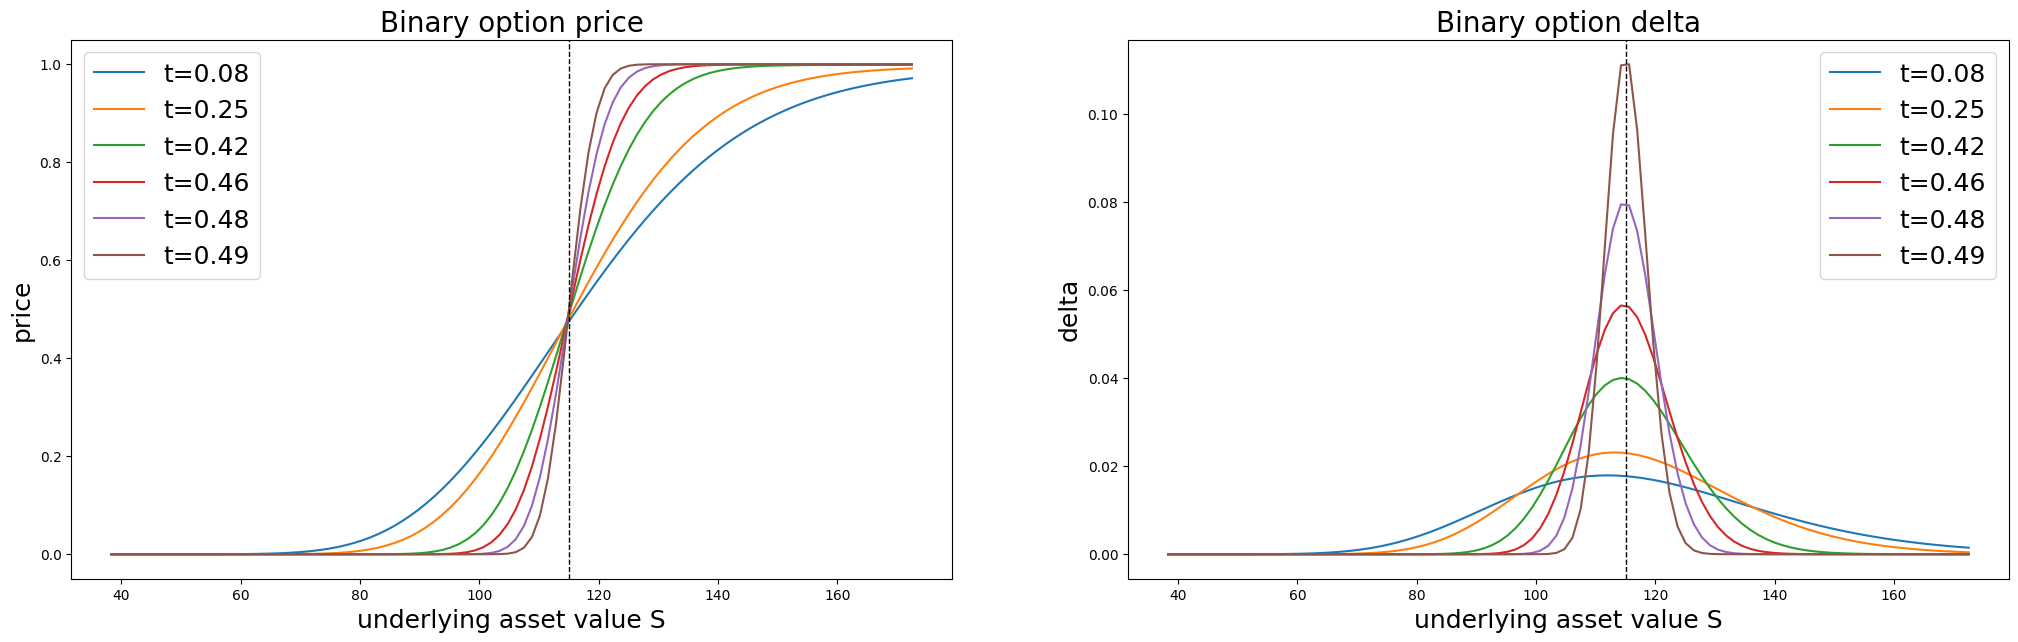

In [10]:
# Option maturity and strike
T = 0.5 # inyears
K = 115

# Other parameters for the price and delta functions
r, sigma_hat = 0.02, 0.3

# Possible values of the underlying asset price S
number_points = 100
spot_prices = np.linspace(K/3, K*3/2, number_points)

dates = [
    1 / 12,
    T / 2,
    T - 1 / 12,
    T - 1 / 24,
    T - 1 / 48,
    T - 1 / 96,
]  # 1 month, option's half-life, 1 month before maturity, + others

price_values = np.zeros(number_points)
delta_values = np.zeros(number_points)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25,7))

for t in dates:    
    price_values = Digit_BS(t=t, S_t=spot_prices, T=T, K=K, r=r, sigma_hat=sigma_hat)
    
    ax1.plot(spot_prices, price_values, label="t=%1.2f" %t)
    
    delta_values = delta_digit_BS(t=t, S_t=spot_prices, T=T, K=K, r=r, sigma_hat=sigma_hat)
    
    ax2.plot(spot_prices, delta_values, label="t=%1.2f" %t)

ax1.axvline(K, linestyle="--", linewidth=1, color="k")
ax2.axvline(K, linestyle="--", linewidth=1, color="k")

ax1.set_title("Binary option price", fontsize=20)
ax1.set_xlabel("underlying asset value S", fontsize=18)
ax1.set_ylabel("price", fontsize=18)
ax1.legend(loc="best", fontsize=18)

ax2.set_title("Binary option delta", fontsize=20)
ax2.set_xlabel("underlying asset value S", fontsize=18)
ax2.set_ylabel("delta", fontsize=18)
ax2.legend(loc="best", fontsize=18)

plt.show()

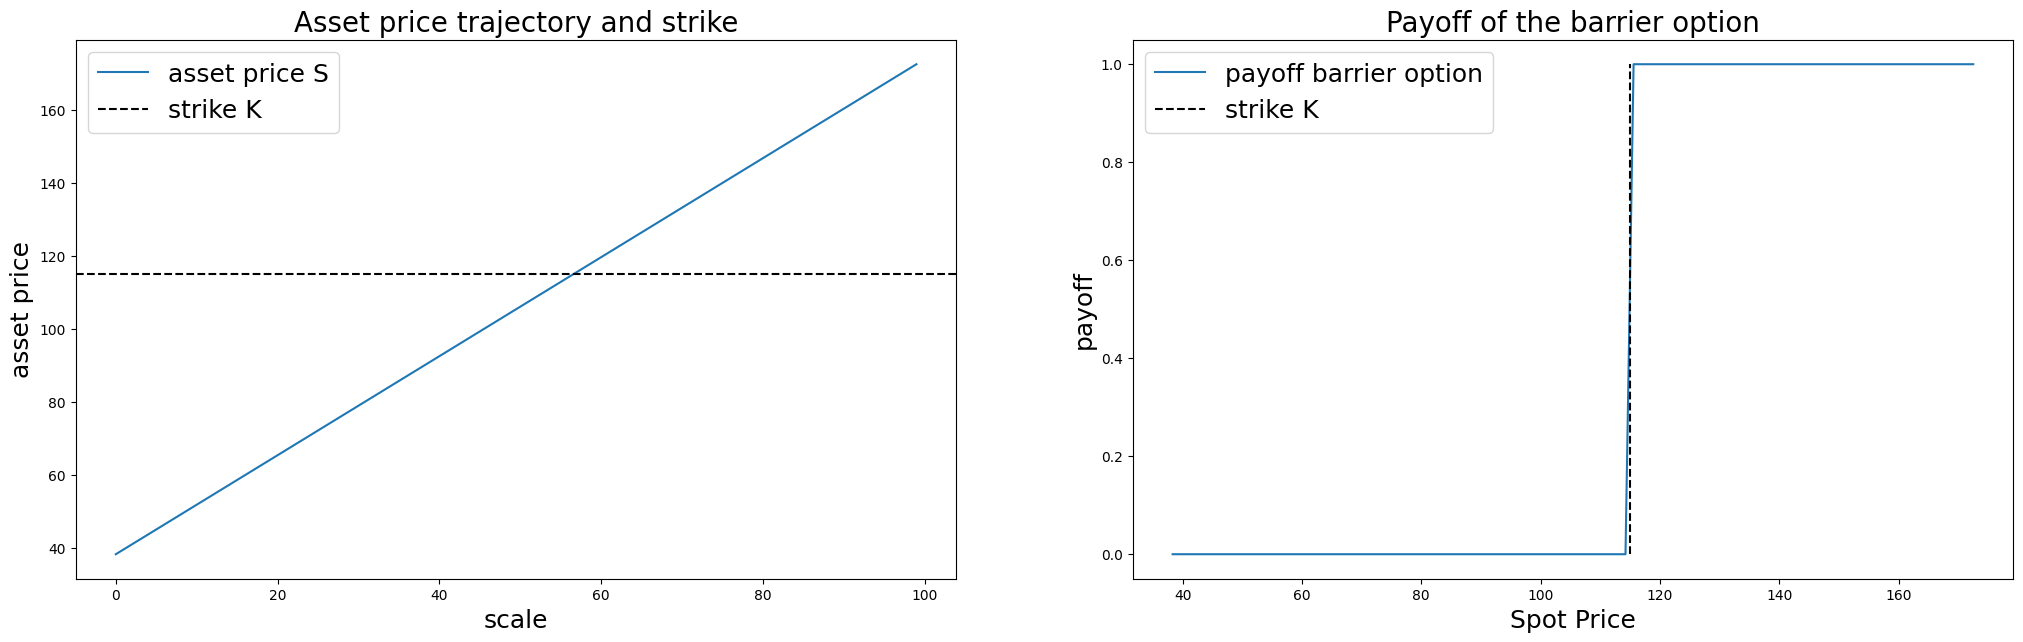

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 7))

ax1.plot(spot_prices, label="asset price S")
ax1.axhline(K, linestyle="--", color="k", label="strike K")
ax1.set_title("Asset price trajectory and strike", fontsize=20)
ax1.set_xlabel("scale", fontsize=18)
ax1.set_ylabel("asset price", fontsize=18)
ax1.legend(loc="best", fontsize=18)

payoff_barrier = [spot_prices[i] >= K for i in range(len(spot_prices))]
ax2.plot(spot_prices, payoff_barrier, label="payoff barrier option")
ax2.vlines(K, 0, 1, colors="k", linestyles="--", label="strike K")
ax2.set_title("Payoff of the barrier option", fontsize=20)
ax2.set_xlabel("Spot Price", fontsize=18)
ax2.set_ylabel("payoff", fontsize=18)
ax2.legend(loc="best", fontsize=18)

plt.show()

#### Q1(b) Simulation of the binary option hedging 

Complete the simulation code below.

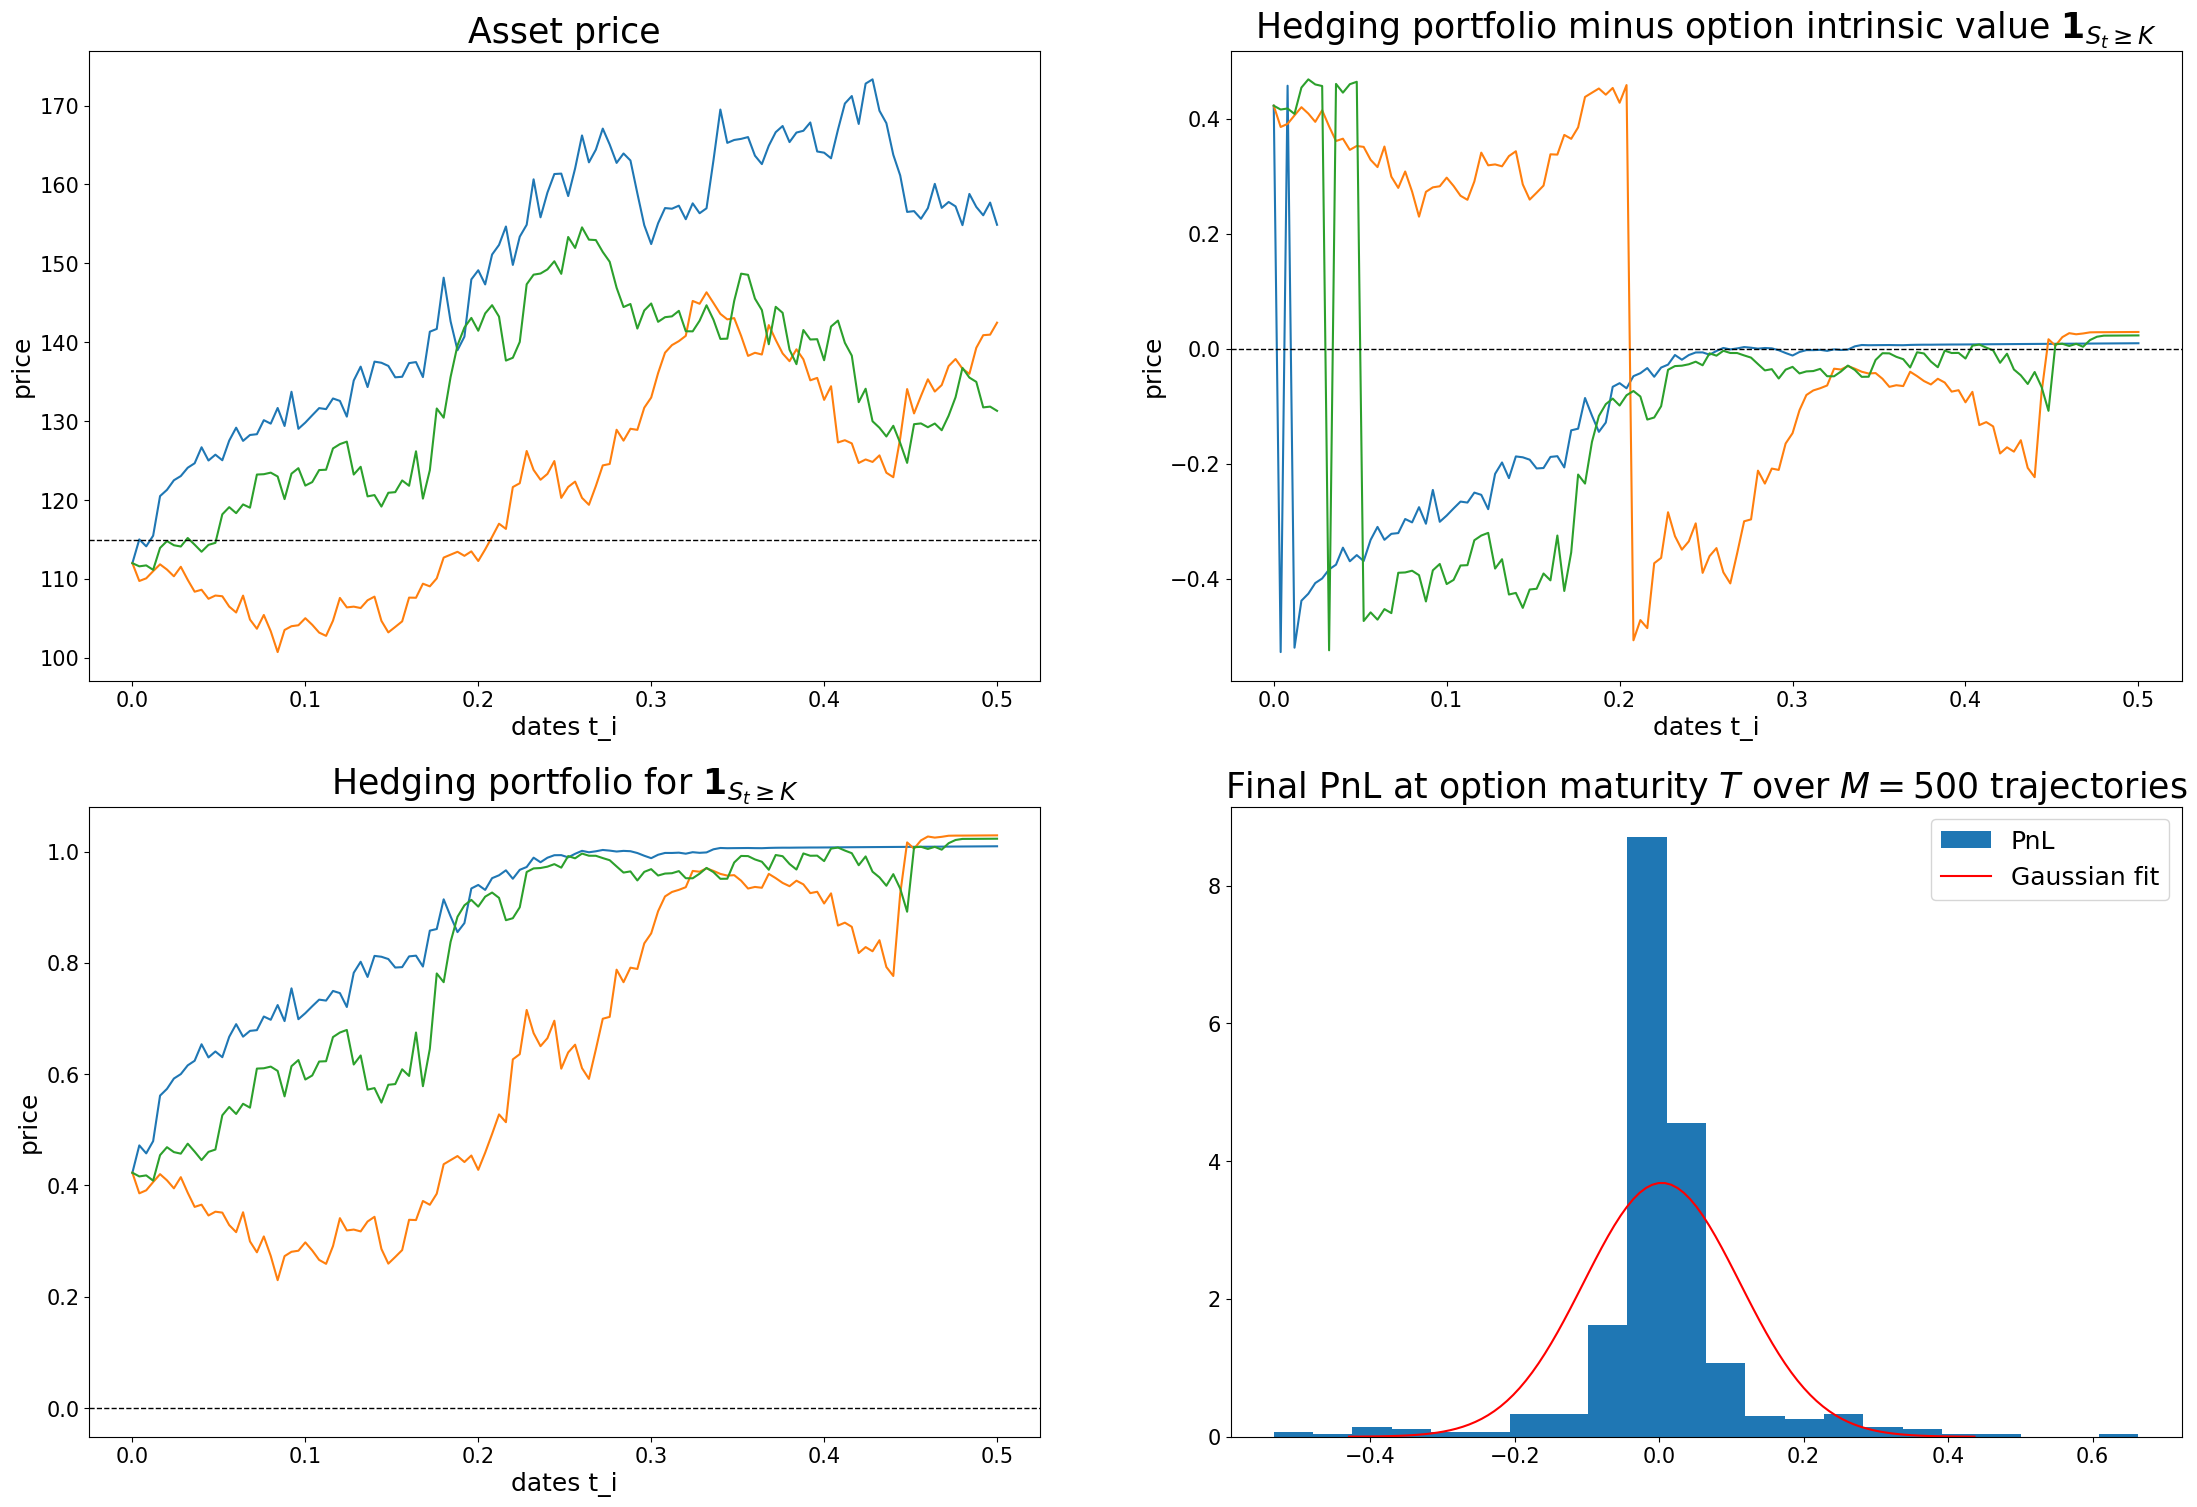

In [12]:
## Option parameters
T = 0.5
K = 115

def payoff_digit(S, K):
    return 1*(S >= K)

# Parameters of the dynamic model for the asset price
S_0 = 112
mu = 0.05
sigma = 0.3

# Parameters for the Black-Scholes price and delta
r = 0.02
sigma_hat = 0.3

## Dates t_1, ..., t_n
n = 125
dates = np.linspace(0, T, n+1)
Delta_T = T/n

# Doing: mimick  the simulation code we used for the call option
# Initial option price (at time t_0 = 0)
V_0 = Digit_BS(t=0, S_t=S_0, T=T, K=K, r=r, sigma_hat=sigma_hat)

# We create the numpy array with size M * (n+1) which will accommodate
# the values of the heding portfolioover the n dates t0, ..., t_{n-1}
# and for all the simulated trajectories
V = V_0 * np.ones((M, n + 1))

for i in range(n):
    # Done: evalute the delta position at the current date t_i
    delta = delta_digit_BS(t=dates[i], S_t=S[:, i], T=T, K=K, r=r, sigma_hat=sigma_hat)

    # Done: evaluate the variation V_{t_{i+1}} - V_{t_i} of the portfolio value, then update V_{t_{i+1}}
    portfolio_variation = delta * (S[:, i + 1] - S[:, i]) + (
        V[:, i] - delta * S[:, i]
    ) * (np.exp(r * Delta_T) - 1)
    V[:, i + 1] = V[:, i] + portfolio_variation

###############
## Plotting
###############
plt.figure(figsize=(27, 18))

# Done: plot 10 asset price trajectories
plt.subplot(2, 2, 1)
plt.tick_params(labelsize=15)

M_1 = 3

plt.plot(dates, S[:M_1, :].T)
plt.axhline(K, linestyle="--", linewidth=1.0, color="k", label="strike")

plt.title("Asset price", fontsize=25)
plt.xlabel("dates t_i", fontsize=18)
plt.ylabel("price", fontsize=18)

# Done: plot the corresponding 10 trajectories of the difference between the hedging portfolio
# and the option's intrinsic value
plt.subplot(2, 2, 2)
plt.tick_params(labelsize=15)

intrinsic_value = payoff_digit(S[:M_1, :], K)

plt.plot(dates, V[:M_1, :].T - intrinsic_value.T)
plt.axhline(y=0, linestyle="--", linewidth=1.0, color="k")

plt.title("Hedging portfolio minus option intrinsic value $\\mathbf{1}_{S_t \\geq K}$", fontsize=25)
plt.xlabel("dates t_i", fontsize=18)
plt.ylabel("price", fontsize=18)

plt.subplot(2, 2, 3)
plt.tick_params(labelsize=15)

plt.plot(dates, V[:M_1, :].T)
plt.axhline(y=0, linestyle="--", linewidth=1.0, color="k")

plt.title(
    "Hedging portfolio for $\\mathbf{1}_{S_t \\geq K}$",
    fontsize=25,
)
plt.xlabel("dates t_i", fontsize=18)
plt.ylabel("price", fontsize=18)

################################################################################
# Last plot: let us show the histogram of the final PnL (at the option maturity),
# now using all the M simulated trajectories
#################################################################################
plt.subplot(2, 2, 4)
plt.tick_params(labelsize=15)

PnL_at_maturity = V[:, -1] - payoff_digit(S[:, -1], K)

plt.hist(PnL_at_maturity, bins=int(np.sqrt(M)), density="True", label="PnL")  # type: ignore

plt.title(
    "Final PnL at option maturity $T$ over $M=%1.0f$ trajectories" % M, fontsize=25
)

# For pleasure
avg_PnL, std_PnL = np.mean(PnL_at_maturity), np.std(PnL_at_maturity)
plt.plot(
    np.linspace(avg_PnL - 4 * std_PnL, avg_PnL + 4 * std_PnL, 100),
    sps.norm.pdf(
        np.linspace(avg_PnL - 4 * std_PnL, avg_PnL + 4 * std_PnL, 100),
        loc=avg_PnL,
        scale=std_PnL,
    ),
    color="red",
    label="Gaussian fit",
)

plt.legend(loc="best", fontsize=18)

plt.show()

- We successfully hedge this option most of the time since we average the PnL near 0.
- The distribution of the PnL is more skewed than for the call option, since the payoff of the binary option is more discontinuous than the payoff of the call option. The gaussian fit is poor.

## End.